# A 4D (x, y, z, t) time-series viewer for STEAM microscopy

**The calculus object at the center of this notebook:** a tracked feature's
position over time is a **vector-valued function of one parameter**,

$$\mathbf r(t) = \big(x(t),\, y(t),\, z(t)\big),$$

exactly the space-curve object from vector calculus (Calc III). Its
derivatives are physical quantities a microscope operator actually cares
about:

$$\mathbf v(t) = \frac{d\mathbf r}{dt}, \qquad
\mathbf a(t) = \frac{d^2\mathbf r}{dt^2}, \qquad
s(t) = \int_0^t |\mathbf v(\tau)|\, d\tau \;\; (\text{arc length}).$$

**Where the "4D" comes from:** `dgs/steam_3d_depth_encoding.py` (this repo,
P9 in `dgs/sbir_portfolio.py`) already proposes adding a depth ($z$) channel
to STEAM's native 2D $(x,y)$ imaging via chromatic-confocal encoding. A
sequence of such depth-resolved frames over pulses ($t$) is the natural 4th
axis. `dgs/steam_4d_viewer.py` (this session) builds a synthetic flowing-cell
trajectory through that 4D space and computes its vector calculus using
`dgs/numerical_methods.py`'s already-tested `velocity`/`acceleration`/
`cumulative_integral` -- reused, not re-derived.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))   # repo root (notebook runs in notebooks/)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from dgs.steam_4d_viewer import (
    synthetic_cell_trajectory, synthetic_steam_frame_stack,
    trajectory_velocity, trajectory_acceleration, trajectory_speed,
    trajectory_arc_length, plot_4d_time_series,
)
from dgs.steam_3d_depth_encoding import depth_range_um
from dgs.numerical_methods import velocity, acceleration, cumulative_integral
print("loaded dgs.steam_4d_viewer")

loaded dgs.steam_4d_viewer


## Part 1 -- the trajectory $\mathbf r(t)$

A synthetic flowing cell: steady flow along $x$, a sinusoidal wobble in $y$
(microfluidic channel drift), and a bounded $z$ oscillation. The $z$ bound
is NOT arbitrary -- it comes straight from `steam_3d_depth_encoding.py`'s
`depth_range_um`, the same formula `dgs/sbir_portfolio.py`'s P9 proposal
uses to budget its chromatic-confocal depth channel.

**What would I actually measure in a lab?** A real STEAM system would track
a feature's centroid frame-to-frame (e.g. by correlation or a simple
intensity-weighted centroid) -- the trajectory below stands in for that
extracted centroid track, not the raw pixel data itself (that's Part 2).

**Questions to ask:** Does the z-oscillation amplitude match what
`depth_range_um` predicts for these spectral-band parameters? Is the x-motion
close to a straight line (steady flow) while y wobbles (channel drift) --
i.e., does the synthetic model match the physical story it claims?

depth_range_um (steam_3d_depth_encoding formula): 4.00 um
trajectory z range actually used: [-1.98, 2.00] um


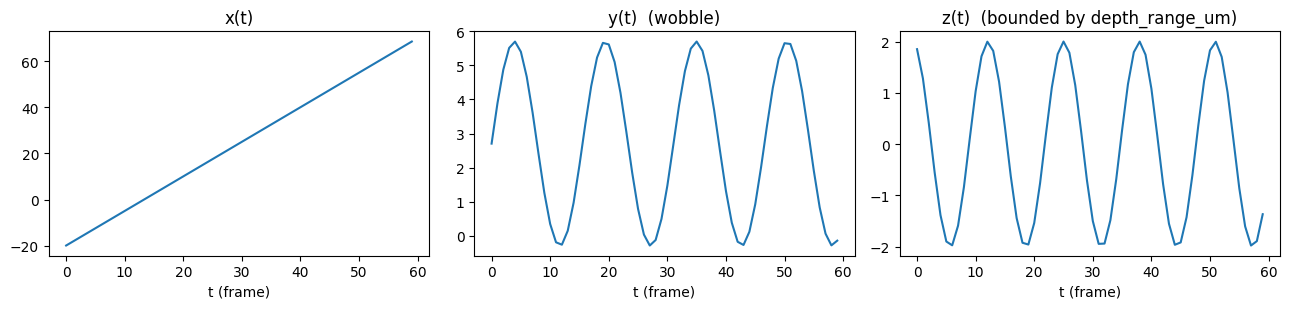

In [2]:
traj = synthetic_cell_trajectory(n_frames=60, xy_extent_um=40.0,
                                  z_band_bandwidth_nm=20.0, axial_dispersion_nm_per_um=5.0,
                                  flow_speed_um_per_frame=1.5, wobble_amplitude_um=3.0, rng_seed=1)

print(f"depth_range_um (steam_3d_depth_encoding formula): {traj['z_range_um']:.2f} um")
print(f"trajectory z range actually used: [{traj['z_um'].min():.2f}, {traj['z_um'].max():.2f}] um")

fig, axs = plt.subplots(1, 3, figsize=(13, 3.2))
axs[0].plot(traj['t'], traj['x_um']); axs[0].set_title('x(t)'); axs[0].set_xlabel('t (frame)')
axs[1].plot(traj['t'], traj['y_um']); axs[1].set_title('y(t)  (wobble)'); axs[1].set_xlabel('t (frame)')
axs[2].plot(traj['t'], traj['z_um']); axs[2].set_title('z(t)  (bounded by depth_range_um)'); axs[2].set_xlabel('t (frame)')
plt.tight_layout(); plt.show()

## Part 2 -- the raw 4D $(x, y, z, t)$ frame stack

Each frame is a 2D Gaussian blob positioned at $(x(t), y(t))$; its brightness
and width depend on how far $z(t)$ is from focus -- a defocus penalty, the
same qualitative behavior a real chromatic-confocal depth channel has (a
particle out of the in-focus plane reads dimmer and blurrier). This is what
`synthetic_steam_frame_stack` renders, and what Part 1's centroid trajectory
would be extracted FROM in a real pipeline.

**What would I actually measure in a lab?** This IS the raw camera/detector
data -- the actual STEAM output per pulse, before any centroid-tracking
algorithm runs on it.

**Questions to ask:** Do frames near $z=0$ (in focus) look visibly brighter
and sharper than frames near the $z$ extremes (out of focus)?

frame stack shape: (60, 64, 64)  (n_frames, H, W)


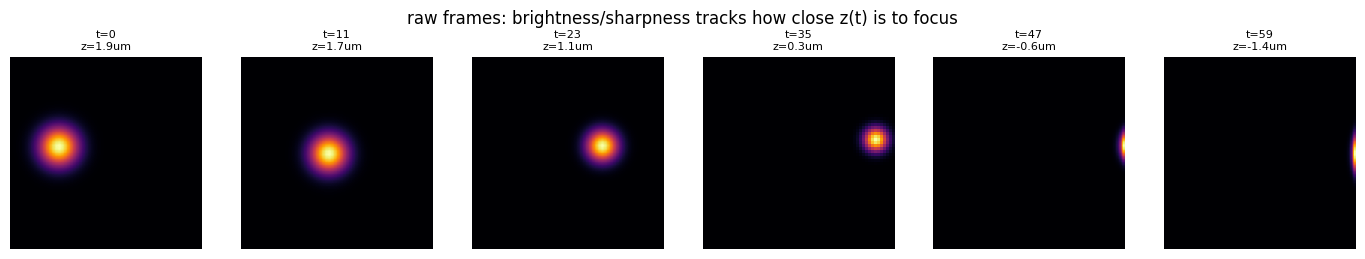

In [3]:
frames = synthetic_steam_frame_stack(traj, frame_size=64, spot_sigma_um=3.0)
print(f"frame stack shape: {frames.shape}  (n_frames, H, W)")

fig, axs = plt.subplots(1, 6, figsize=(14, 2.6))
preview_idx = np.linspace(0, len(traj['t']) - 1, 6).astype(int)
for ax, i in zip(axs, preview_idx):
    ax.imshow(frames[i], cmap='inferno', origin='lower')
    ax.set_title(f"t={i}\nz={traj['z_um'][i]:.1f}um", fontsize=8)
    ax.axis('off')
plt.suptitle('raw frames: brightness/sharpness tracks how close z(t) is to focus')
plt.tight_layout(); plt.show()

## Part 3 -- velocity $\mathbf v(t)$ and acceleration $\mathbf a(t)$

$$\mathbf v(t) = \frac{d\mathbf r}{dt}, \qquad \mathbf a(t) = \frac{d^2\mathbf r}{dt^2}$$

computed component-by-component via `dgs/numerical_methods.py`'s
`velocity`/`acceleration` (finite-difference derivatives, already tested
elsewhere in this repo) -- no new calculus machinery, just applied to a new
signal.

**Sanity check first:** a trajectory with zero wobble and zero z-motion is
pure constant-velocity straight-line flow -- $\mathbf v(t)$ should come out
CONSTANT and $\mathbf a(t)$ should come out ZERO (up to finite-difference
edge effects). This is exactly `tests/test_steam_4d_viewer.py`'s
`test_trajectory_velocity_of_uniform_motion_is_constant` check, run visually
here.

**What would I actually measure in a lab?** Velocity is directly useful for
flow-rate calibration (cells/second past a point); acceleration flags
anomalous events (a cell snagging, channel turbulence) that a constant-flow
model wouldn't predict.

**MATLAB equivalent:** `gradient(x, t)` twice, same finite-difference idea.

straight-line flow: vx interior mean=2.0000 um/frame (expected 2.0), std=0.00e+00
                    ax interior mean=0.00e+00 (expected ~0)


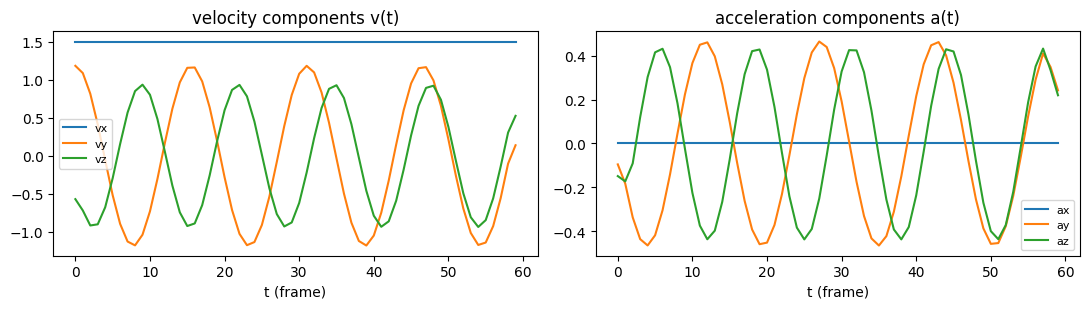

In [4]:
straight_traj = synthetic_cell_trajectory(n_frames=40, wobble_amplitude_um=0.0,
                                            z_band_bandwidth_nm=1e-6, flow_speed_um_per_frame=2.0)
v_straight = trajectory_velocity(straight_traj)
a_straight = trajectory_acceleration(straight_traj)
print(f"straight-line flow: vx interior mean={v_straight['vx'][2:-2].mean():.4f} um/frame "
      f"(expected 2.0), std={v_straight['vx'][2:-2].std():.2e}")
print(f"                    ax interior mean={a_straight['ax'][2:-2].mean():.2e} (expected ~0)")

v = trajectory_velocity(traj)
a = trajectory_acceleration(traj)
fig, axs = plt.subplots(1, 2, figsize=(11, 3.2))
axs[0].plot(traj['t'], v['vx'], label='vx'); axs[0].plot(traj['t'], v['vy'], label='vy')
axs[0].plot(traj['t'], v['vz'], label='vz'); axs[0].legend(fontsize=8)
axs[0].set_title('velocity components v(t)'); axs[0].set_xlabel('t (frame)')
axs[1].plot(traj['t'], a['ax'], label='ax'); axs[1].plot(traj['t'], a['ay'], label='ay')
axs[1].plot(traj['t'], a['az'], label='az'); axs[1].legend(fontsize=8)
axs[1].set_title('acceleration components a(t)'); axs[1].set_xlabel('t (frame)')
plt.tight_layout(); plt.show()

## Part 4 -- speed $|\mathbf v(t)|$ and arc length $s(t)$

$$s(t) = \int_0^t |\mathbf v(\tau)|\, d\tau$$

computed via `numerical_methods.cumulative_integral` (trapezoid rule) applied
to the speed -- the numerical Fundamental Theorem of Calculus: differentiate
$s(t)$ and you get the speed back.

**Sanity check:** for the same straight-line trajectory as Part 3, arc length
should equal speed times elapsed time exactly (a straight path's length IS
just distance = rate x time) -- `tests/test_steam_4d_viewer.py`'s
`test_trajectory_arc_length_of_straight_line_matches_distance` checks this
directly, reproduced here.

**What would I actually measure in a lab?** Total path length over an
observation window, divided by real elapsed time (not frame count), gives a
calibrated average flow speed -- useful for throughput characterization
(cells/second, matching the cadence of `dgs/sbir_portfolio.py`'s P2 STEAM
proposal's "10,000 cells/second" framing).

straight-line arc length: 78.00 um (expected speed*time = 78.00 um)


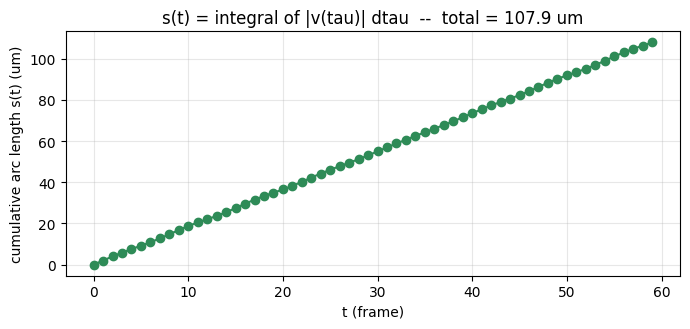

mean speed: 1.83 um/frame


In [5]:
arc_straight = trajectory_arc_length(straight_traj)
expected = 2.0 * (len(straight_traj['t']) - 1)
print(f"straight-line arc length: {arc_straight['total_length']:.2f} um "
      f"(expected speed*time = {expected:.2f} um)")

arc = trajectory_arc_length(traj)
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(traj['t'], arc['s_t'], 'o-', color='seagreen')
ax.set_xlabel('t (frame)'); ax.set_ylabel('cumulative arc length s(t) (um)')
ax.set_title(f"s(t) = integral of |v(tau)| dtau  --  total = {arc['total_length']:.1f} um")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"mean speed: {arc['speed'].mean():.2f} um/frame")

## Part 5 -- the combined 4D viewer

`plot_4d_time_series` puts Parts 1-4 in one figure: raw frame small-multiples
across $t$, the 3D trajectory $\mathbf r(t)$ colored by time with velocity
vectors overlaid, and the speed/arc-length curve -- everything an operator
would need to assess a tracked feature's motion through the depth-resolved
STEAM field of view in one view.

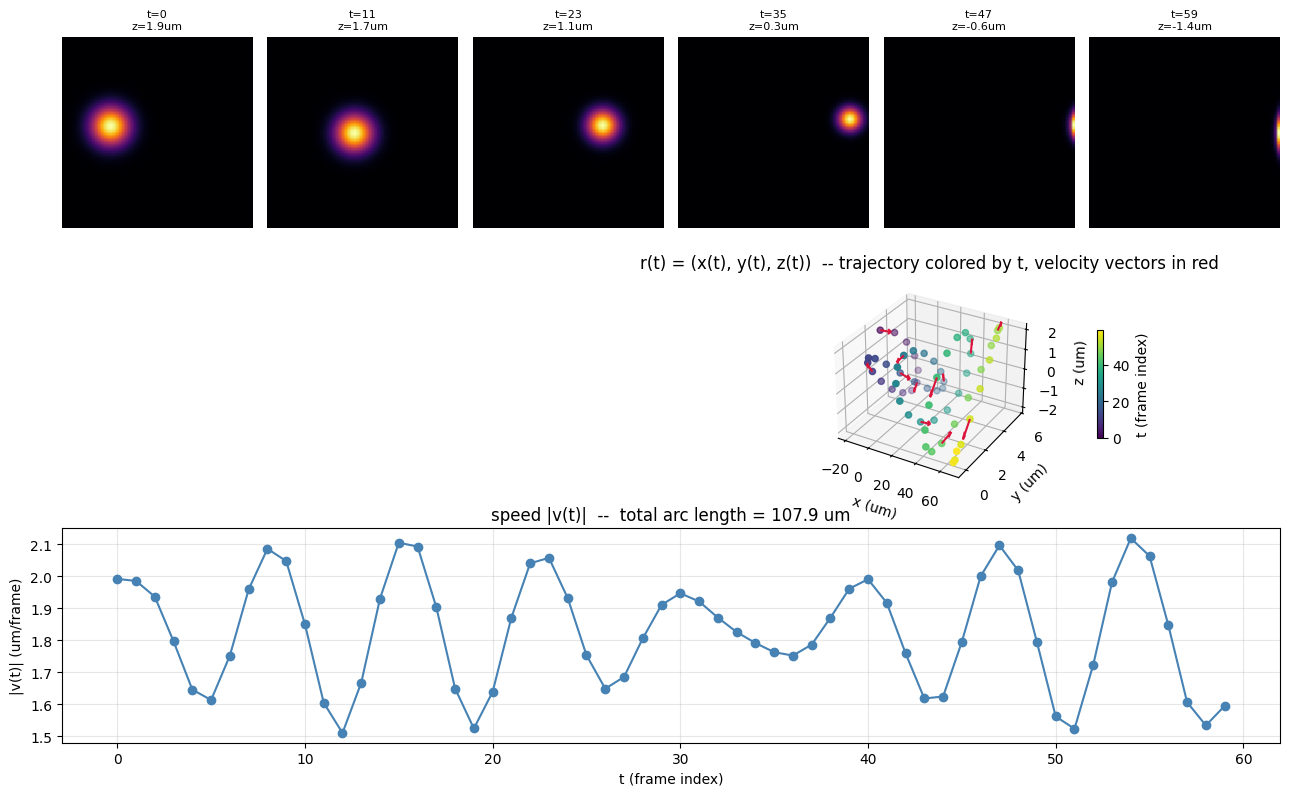

In [6]:
fig = plot_4d_time_series(traj, frames, n_preview_frames=6)
plt.show()

## Summary

| Calculus object | Physical meaning here | Function |
|---|---|---|
| $\mathbf r(t)=(x,y,z)(t)$ | tracked feature's position | `synthetic_cell_trajectory` |
| $\mathbf v(t)=d\mathbf r/dt$ | flow velocity | `trajectory_velocity` (`numerical_methods.velocity`) |
| $\mathbf a(t)=d^2\mathbf r/dt^2$ | flow anomalies (snags, turbulence) | `trajectory_acceleration` |
| $\vert\mathbf v(t)\vert$ | instantaneous speed | `trajectory_speed` |
| $s(t)=\int\vert\mathbf v\vert dt$ | path length, throughput calibration | `trajectory_arc_length` (`numerical_methods.cumulative_integral`) |

All four calculus primitives are `dgs/numerical_methods.py` functions already
tested elsewhere in this repo -- this notebook is a new APPLICATION of
existing calculus machinery to a new (synthetic) 4D STEAM dataset, not new
math. `dgs/steam_4d_viewer.py`'s own test suite (14 tests) checks the
straight-line sanity cases shown live in Parts 3-4 above.